# Doble Diferencia de Franjas Horarias
## Un control interno dentro del mismo día

Idea del diseño: el tráfico escolar opera de 7 a 9; a las 10-12 ya no. El clima, la
temporada y los eventos del día son compartidos por ambas franjas del mismo día y la
misma estación. El contraste doble:

    gap(fecha, estación) = log(nivel pico 7-9) - log(nivel fuera de pico 10-12)
    gap ~ clase + controles

identifica cuánto se ABRE la brecha matutina en periodos de clase, descontando por
construcción cualquier confusor a nivel día-estación. Es la forma colapsada de un panel
apilado de las dos franjas con efectos fijos de fecha × estación: la primera diferencia
se identifica dentro de cada celda fecha-estación y beta comparando esas brechas entre
fechas lectivas y de vacaciones.

Por qué CO es el trazador del tráfico (respaldo de literatura): la red de monitoreo
de borde de carretera de la EPA muestra que "carbon monoxide (CO) are typically
higher near roadways than elsewhere in the urban environment" mientras que las
partículas responden sobre todo al fondo urbano y apenas se relacionan con el
volumen vehicular (DeWinter et al., 2018, Atmospheric Environment 183, 94-105,
doi:10.1016/j.atmosenv.2018.04.003). Eso es lo que se espera en este análisis: si
la asociación viene del tráfico de entrada escolar, debe vivir en CO (y NO2) y no
en PM.

**Data access / Acceso a los datos.** The SIMA measurements used here are not
redistributed in this repository (SIMA provided them for this study on the condition
that they are not disseminated); the repository holds the code, the official school
calendar and all derived results. This notebook reads files that notebooks 00 and 01
build from those measurements, and its configuration cell stops with a clear message
if they are missing. To rebuild them, request the annual workbooks from SIMA, place
them in `data_raw/` and run notebook 00 (its header gives the exact file format). /
Las mediciones de SIMA no se redistribuyen en este repositorio (SIMA las entregó para
este estudio con la condición de no difundirlas); el repositorio contiene el código, el
calendario oficial y todos los resultados derivados. Este notebook lee archivos que los
notebooks 00 y 01 construyen a partir de esas mediciones, y su celda de configuración
se detiene con un mensaje claro si faltan. Para reconstruirlos, solicite los libros
anuales a SIMA, colóquelos en `data_raw/` y corra el notebook 00 (su encabezado da el
formato exacto).

**Role in the analysis / Papel en el análisis.** PRIMARY ANALYSIS: the conceptually motivated within-day double difference (07:00–09:00 arrival window vs the same-day 10:00–12:00 control window) with weekly-clustered inference, its weekday/weekend contrasts, the calendar-based falsification test, leave-one-zone-out and the residual diagnostics. / ANÁLISIS PRINCIPAL: la doble diferencia dentro del día motivada conceptualmente (ventana de entrada 07:00–09:00 contra la ventana de control 10:00–12:00 del mismo día) con inferencia agrupada por semana, sus contrastes entre semana y fin de semana, la prueba de falsificación basada en calendario, el leave-one-zone-out y los diagnósticos de residuos. The analytical hierarchy of the whole repository is stated in the README. / La jerarquía analítica de todo el repositorio está en el README.

## 1. Configuración inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import json
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

contaminantes = ['CO', 'NO2', 'O3', 'PM10', 'PM2.5']

output_dir = Path('../data_processed')
resultados_dir = output_dir / 'resultados_metodos'
graficos_dir = output_dir / 'graficos_metodos'
resultados_dir.mkdir(exist_ok=True)
graficos_dir.mkdir(exist_ok=True)

print("Librerías importadas exitosamente")

# Verificación de los datos de entrada (no se redistribuyen; ver la nota del encabezado)
# / Input data check (not redistributed; see the note in the header)
archivos_requeridos = [output_dir / 'panel_pico_hibrido.csv',
                       output_dir / 'gaps_franjas_hibrido.csv',
                       output_dir / 'gaps_franjas_MIMA.csv']
faltantes = [str(a) for a in archivos_requeridos if not a.exists()]
if faltantes:
    raise FileNotFoundError(
        "Faltan archivos derivados de las mediciones de SIMA, que no se redistribuyen en este repositorio. "
        "Solicite los libros anuales a SIMA, colóquelos en data_raw/ y corra los notebooks 00 y 01. / "
        "Files derived from the SIMA measurements are missing; they are not redistributed in this repository. "
        "Request the annual workbooks from SIMA, place them in data_raw/ and run notebooks 00 and 01. "
        f"Faltantes / missing: {faltantes}")
print(f"Datos de entrada encontrados / input data found: {len(archivos_requeridos)} archivos")

Librerías importadas exitosamente
Datos de entrada encontrados / input data found: 3 archivos


## 2. Funciones del estimador SUR con errores agrupados

Las cinco ecuaciones (una por contaminante) comparten regresores, así que el SUR
coincide con OLS ecuación por ecuación; la covarianza conjunta se agrupa por semana
ISO y la prueba de Wald contesta si 'clase' es cero en las cinco a la vez.

### Las matemáticas de la doble diferencia

La tabla 2×2 del diseño (promedios de log-concentración):

| | Franja pico 7-9 | Franja control 10-12 |
|---|---|---|
| Días de clase | $\mu + \pi + \kappa + \beta$ | $\mu + \kappa$ |
| Días de vacaciones | $\mu + \pi$ | $\mu$ |

$\pi$: lo que la mañana pico tiene de especial SIEMPRE; $\kappa$: lo que los días de
clase tienen de especial A TODA HORA (la temporada); $\beta$: lo que la mañana pico
tiene de especial SOLO en días de clase — el efecto que buscamos.

$$ \beta = \underbrace{(\text{pico}-\text{control})_{\text{clase}}}_{1^{a}\ \text{diferencia}} \; - \; \underbrace{(\text{pico}-\text{control})_{\text{vacaciones}}}_{1^{a}\ \text{diferencia}} $$

La primera resta ya viene hecha dentro de la variable gap (notebook 01); la segunda
la hace la regresión $\text{gap}_{st} = \alpha + \beta\,\text{clase}_t + \text{controles} + \varepsilon_{st}$:
el coeficiente de 'clase' sobre el gap ES la doble diferencia.

### La covarianza agrupada y la prueba conjunta

Los 5 gaps (uno por contaminante) comparten regresores, así que estimar las 5
ecuaciones como sistema (SUR) da los mismos $\hat\beta_j$ que OLS una por una; lo que
sí se estima en conjunto es su COVARIANZA. Agrupando por semana $g = 1,\dots,G$:

$$ \hat V = A\Big(\sum_{g=1}^{G} s_g^{\vphantom{\prime}} s_g'\Big)A' \cdot \frac{G}{G-1}\cdot\frac{n-1}{n-k}, \qquad s_g = \operatorname{vec}\big(X_g'\,\hat U_g\big), \quad A = I_5 \otimes (X'X)^{-1} $$

($X_g$, $\hat U_g$: regresores y residuos de la semana $g$; el último factor es la
corrección de grados de libertad estándar de cluster). Con $b$ = vector de los 5
coeficientes de 'clase' y $V_b$ su bloque de $\hat V$:

$$ W = b'\,V_b^{-1}\,b \;\sim\; \chi^2_5 \quad \text{bajo } H_0:\ \beta_{\text{CO}} = \beta_{\text{NO}_2} = \beta_{\text{O}_3} = \beta_{\text{PM}_{10}} = \beta_{\text{PM}_{2.5}} = 0 $$

Una sola p conjunta para la pregunta "¿'clase' mueve ALGO en el sistema?", en lugar
de 5 pruebas sueltas que habría que corregir por separado.

### Hipótesis que se prueban

- Por contaminante: $H_0\!: \beta_j = 0$ (el periodo lectivo no ensancha la brecha
  matutina del contaminante $j$) contra $H_1\!: \beta_j \neq 0$.
- Conjunta (Wald): $H_0\!: \beta_{\text{CO}} = \beta_{\text{NO}_2} = \beta_{\text{O}_3} = \beta_{\text{PM}_{10}} = \beta_{\text{PM}_{2.5}} = 0$
  (los cinco contaminantes del estudio) contra la alternativa de que al menos una
  difiere de cero.
- Las pruebas de falsación prueban la misma nula donde SABEMOS que es cierta (clases
  falsas por paridad de semana ISO dentro de un solo régimen): rechazar ahí delataría
  un diseño que inventa efectos. Se leen con cuidado: semanas consecutivas no son
  intercambiables en todo, así que un resultado nulo apoya el diseño sin demostrarlo.

### Supuestos del diseño (y qué diagnóstico examina cada uno)

Ningún diagnóstico verifica su supuesto por completo: cada uno lo examina y aporta
evidencia parcial sobre él.

1. **La franja control es un pseudo-control válido**: lo que confunde (clima,
   temporada, eventos del día) pega igual a las 7-9 que a las 10-12 del mismo día, o
   al menos su evolución dentro de la mañana no difiere entre días lectivos y de
   vacaciones más allá del tráfico de entrada. El perfil horario del notebook 09 (las
   horas sin actividad escolar dan coeficiente ~0) y las pruebas de falsación de este
   notebook lo examinan, pero no demuestran que 10-12 sea un control perfecto: la
   meteorología, el tráfico y la química cambian a lo largo de la mañana.
2. **El indicador de periodo lectivo está bien medido**: 'clase' viene del calendario
   oficial SEP con fechas verificadas en el DOF (notebook 00). El calendario respalda
   la clasificación del régimen, no la asistencia efectiva de cada día: los viernes de
   Consejo Técnico no se marcan, y los fines de semana dentro del periodo lectivo se
   codifican como fechas lectivas aunque no tienen asistencia, así que entran
   directamente al estimado agrupado; por eso el contraste solo entre semana se reporta
   aparte (sección 3). Weekends within the school term are coded as school-term dates
   even though there is no student attendance, so they enter the pooled estimate
   directly; weekday-only estimates are therefore reported separately. Lo más plausible
   es que medir mal el indicador atenúe el efecto.
3. **Sin derrame entre franjas**: el tráfico escolar de 7-9 no debe alterar la franja
   10-12 del mismo día. Para un contaminante primario relativamente inerte como el CO,
   la persistencia en la franja control probablemente ATENÚA el contraste estimado (lo
   mismo puede esperarse de PM10 y PM2.5). Eso no está garantizado para contaminantes
   secundarios como el ozono, cuya concentración matutina refleja tanto la titulación
   por NO como la formación fotoquímica con la luz solar: ahí la dirección del sesgo no
   va necesariamente hacia cero.
4. **Errores con dependencia a lo más semanal**: se agrupa por semana ISO. Los
   diagnósticos de la sección 5 (Durbin-Watson y la ACF de los residuos hasta 21
   rezagos) examinan cuánta correlación serial queda y cuánto dura; aportan evidencia
   parcial, no una demostración. El wild bootstrap del notebook 08 mejora la precisión
   en muestras finitas de la inferencia con el cluster elegido, pero no protege contra
   dependencia entre semanas, que la ACF muestra pequeña.

In [2]:
def matriz_diseno(df, especificacion='preferida'):
    """
    Construye la matriz de diseño: constante + clase + efectos fijos.
    'preferida' = estación + mes + día de semana; 'sin_mes' = estación + día de semana
    (para ver qué aportan los efectos de mes); 'estacion' = solo efectos de zona.
    """
    piezas = [pd.get_dummies(df['estacion'], prefix='est', drop_first=True).astype(float)]
    if especificacion == 'preferida':
        piezas.append(pd.get_dummies(df['mes'], prefix='mes', drop_first=True).astype(float))
    if especificacion in ('preferida', 'sin_mes'):
        piezas.append(pd.get_dummies(df['dow'], prefix='dow', drop_first=True).astype(float))
    X = pd.concat([pd.Series(1.0, index=df.index, name='const'),
                   df['clase'].astype(float)] + piezas, axis=1)
    return X

def sur_wald_cluster(df, X, columnas_y, cluster):
    """
    OLS por ecuación (regresores idénticos) + covarianza conjunta agrupada -> Wald conjunto.
    """
    Xv = X.values
    n, k = Xv.shape
    XtX_inv = np.linalg.inv(Xv.T @ Xv)
    Y = df[columnas_y].values
    B = XtX_inv @ Xv.T @ Y
    U = Y - Xv @ B
    J = len(columnas_y)
    grupos = df[cluster].values
    orden = np.argsort(grupos, kind='stable')
    Xg, Ug, gg = Xv[orden], U[orden], grupos[orden]
    S = np.zeros((J * k, J * k))
    inicios = np.flatnonzero(np.r_[True, gg[1:] != gg[:-1]])
    fines = np.r_[inicios[1:], len(gg)]
    G = len(inicios)
    for s, e in zip(inicios, fines):
        sg = (Xg[s:e].T @ Ug[s:e]).T.reshape(-1)
        S += np.outer(sg, sg)
    A = np.kron(np.eye(J), XtX_inv)
    V = A @ S @ A
    V *= (G / (G - 1)) * ((n - 1) / (n - k))
    idx_clase = X.columns.get_loc('clase')
    seleccion = [j * k + idx_clase for j in range(J)]
    b = B[idx_clase, :]
    Vb = V[np.ix_(seleccion, seleccion)]
    W = float(b @ np.linalg.inv(Vb) @ b)
    p_chi2 = float(1 - stats.chi2.cdf(W, J))
    resultados_por_var = {}
    for j, col in enumerate(columnas_y):
        se = float(np.sqrt(Vb[j, j]))
        z = b[j] / se
        resultados_por_var[col] = {
            'beta': round(float(b[j]), 4), 'se': round(se, 4),
            'pct': round((np.exp(b[j]) - 1) * 100, 2),
            'ci_lo_pct': round((np.exp(b[j] - 1.96 * se) - 1) * 100, 2),
            'ci_hi_pct': round((np.exp(b[j] + 1.96 * se) - 1) * 100, 2),
            'p': round(2 * (1 - stats.norm.cdf(abs(z))), 6)}
    return {'por_var': resultados_por_var, 'wald_chi2': round(W, 2),
            'p_chi2': round(p_chi2, 6), 'G_clusters': int(G), 'n': int(n), 'k': int(k)}

print("Funciones del estimador listas")

Funciones del estimador listas


## 3. Estimación principal (con las dos imputaciones)

Además del efecto principal se calculan, con el mismo estimador, (a) el contraste
solo entre semana y solo fin de semana, (b) las pruebas de falsación basadas en el
calendario (clase falsa por paridad de semana ISO dentro de un solo régimen), (c) el
análisis de influencia leave-one-zone-out (el modelo completo se reestima seis veces
quitando una zona a la vez y se reporta el rango de los efectos), (d) la triple
diferencia entre semana menos fin de semana y (e) el mismo estimador sin los efectos
fijos de mes, para ver cuánto de la brecha cruda se debe a la temporada: las vacaciones
caen en diciembre, enero, Semana Santa y verano, así que comparar brechas de días
lectivos y de vacaciones sin controlar el mes mezcla el calendario escolar con el ciclo
estacional de cada contaminante. Sobre la prueba de falsación conviene
ser claros: solo examina un patrón concreto (semanas alternadas), no descarta
confusión estacional, tendencias largas ni diferencias entre periodos vacacionales
(Navidad, Semana Santa y verano quedan juntos en el estrato de vacaciones). Sobre el
leave-one-zone-out: si un choque común afectara a todas las zonas a la vez (lluvias
torrenciales, cambios laborales o industriales), quitar una zona no lo detectaría.

In [3]:
columnas_gap = [f'gap_{c}' for c in contaminantes]
resultados = {}

for nombre_dataset in ['hibrido', 'MIMA']:
    gaps = pd.read_csv(f'../data_processed/gaps_franjas_{nombre_dataset}.csv', parse_dates=['date'])
    salida = {'n': len(gaps), 'gap_promedio_por_regimen': {}}
    for cl in (0, 1):
        sub = gaps[gaps['clase'] == cl]
        salida['gap_promedio_por_regimen'][f'clase_{cl}'] = {
            c: round(sub[f'gap_{c}'].mean(), 3) for c in contaminantes}

    X = matriz_diseno(gaps, 'preferida')
    salida['did_franjas'] = sur_wald_cluster(gaps, X, columnas_gap, 'wk')

    # El efecto debería concentrarse ENTRE SEMANA (no hay school-run en sábado y domingo)
    for nombre, sub in (('solo_entre_semana', gaps[gaps['finde'] == 0]),
                        ('solo_fin_de_semana', gaps[gaps['finde'] == 1])):
        Xs = matriz_diseno(sub, 'preferida')
        salida[nombre] = sur_wald_cluster(sub, Xs, columnas_gap, 'wk')

    # Pruebas de falsación: "clase falsa" por paridad de semana dentro de un solo régimen
    for nombre, sub in (('placebo_vacaciones', gaps[gaps['clase'] == 0]),
                        ('placebo_clases', gaps[gaps['clase'] == 1])):
        s = sub.copy()
        s['clase'] = (s['wknum'] % 2).astype(int)
        Xs = matriz_diseno(s, 'preferida')
        salida[nombre] = sur_wald_cluster(s, Xs, columnas_gap, 'wk')

    # Influencia: leave-one-zone-out (se reestima el modelo completo quitando cada zona)
    salida['leave_one_zone_out'] = {}
    for zona_fuera in sorted(gaps['estacion'].unique()):
        sub = gaps[gaps['estacion'] != zona_fuera]
        Xs = matriz_diseno(sub, 'preferida')
        r_l = sur_wald_cluster(sub, Xs, columnas_gap, 'wk')
        salida['leave_one_zone_out'][f'sin_{zona_fuera}'] = {
            'p_conjunto': r_l['p_chi2'],
            **{c: {k: r_l['por_var'][f'gap_{c}'][k] for k in ('pct', 'ci_lo_pct', 'ci_hi_pct', 'p')}
               for c in contaminantes}}

    # Qué aportan los efectos fijos de mes: mismo estimador con zona + día de semana, sin mes
    X_sin_mes = matriz_diseno(gaps, 'sin_mes')
    salida['sin_efectos_fijos_de_mes'] = sur_wald_cluster(gaps, X_sin_mes, columnas_gap, 'wk')

    # Triple diferencia explícita: efecto entre semana MENOS efecto en fin de semana
    salida['triple_dif_wd_menos_we'] = {}
    for c in contaminantes:
        b_wd = salida['solo_entre_semana']['por_var'][f'gap_{c}']
        b_we = salida['solo_fin_de_semana']['por_var'][f'gap_{c}']
        delta = b_wd['beta'] - b_we['beta']
        se_aprox = np.sqrt(b_wd['se']**2 + b_we['se']**2)
        z = delta / se_aprox
        salida['triple_dif_wd_menos_we'][c] = {
            'delta_beta': round(delta, 4), 'se_aprox': round(se_aprox, 4),
            'p_aprox': round(2 * (1 - stats.norm.cdf(abs(z))), 4)}

    resultados[nombre_dataset] = salida

    print("=" * 70)
    print(f"DOBLE DIFERENCIA DE FRANJAS — dataset {nombre_dataset}")
    print("=" * 70)
    did = salida['did_franjas']
    print(f"Efecto conjunto: chi2 = {did['wald_chi2']} | p = {did['p_chi2']} "
          f"(G = {did['G_clusters']} semanas, n = {did['n']})")
    for c in contaminantes:
        e = did['por_var'][f'gap_{c}']
        print(f"  {c}: {e['pct']:+.2f}% [{e['ci_lo_pct']}, {e['ci_hi_pct']}] p = {e['p']}")
    print(f"Entre semana p = {salida['solo_entre_semana']['p_chi2']} | "
          f"fin de semana p = {salida['solo_fin_de_semana']['p_chi2']}")
    print(f"Clase falsa dentro de vacaciones p = {salida['placebo_vacaciones']['p_chi2']} | "
          f"dentro de clases p = {salida['placebo_clases']['p_chi2']}")
    lozo_co = [r_l['CO']['pct'] for r_l in salida['leave_one_zone_out'].values()]
    lozo_p = [r_l['p_conjunto'] for r_l in salida['leave_one_zone_out'].values()]
    print(f"Leave-one-zone-out (CO): efecto entre {min(lozo_co):+.1f}% y {max(lozo_co):+.1f}% | "
          f"p conjunto entre {min(lozo_p):.4f} y {max(lozo_p):.4f}")
    print("Sin efectos fijos de mes (zona + día de semana) contra la especificación preferida:")
    for c in contaminantes:
        e0 = salida['sin_efectos_fijos_de_mes']['por_var'][f'gap_{c}']
        e1 = did['por_var'][f'gap_{c}']
        print(f"  {c}: sin mes {e0['pct']:+.1f}% (p = {e0['p']}) -> con mes {e1['pct']:+.1f}% (p = {e1['p']})")

with open(resultados_dir / 'did_franjas.json', 'w') as f:
    json.dump(resultados, f, indent=2, ensure_ascii=False)
print(f"\nGuardado en: {resultados_dir / 'did_franjas.json'}")

DOBLE DIFERENCIA DE FRANJAS — dataset hibrido
Efecto conjunto: chi2 = 24.11 | p = 0.000207 (G = 158 semanas, n = 6576)
  CO: +4.56% [1.49, 7.71] p = 0.003312
  NO2: +1.02% [-6.15, 8.74] p = 0.786724
  O3: -2.61% [-12.67, 8.61] p = 0.634717
  PM10: -0.54% [-5.68, 4.89] p = 0.842731
  PM2.5: +0.52% [-4.45, 5.75] p = 0.84075
Entre semana p = 3.4e-05 | fin de semana p = 0.052398
Clase falsa dentro de vacaciones p = 0.046307 | dentro de clases p = 0.506341
Leave-one-zone-out (CO): efecto entre +3.9% y +5.1% | p conjunto entre 0.0001 y 0.0065
Sin efectos fijos de mes (zona + día de semana) contra la especificación preferida:
  CO: sin mes +6.3% (p = 0.0) -> con mes +4.6% (p = 0.003312)
  NO2: sin mes +6.5% (p = 0.018969) -> con mes +1.0% (p = 0.786724)
  O3: sin mes +5.6% (p = 0.290781) -> con mes -2.6% (p = 0.634717)
  PM10: sin mes +1.8% (p = 0.315052) -> con mes -0.5% (p = 0.842731)
  PM2.5: sin mes +9.0% (p = 0.008481) -> con mes +0.5% (p = 0.84075)


DOBLE DIFERENCIA DE FRANJAS — dataset MIMA
Efecto conjunto: chi2 = 21.83 | p = 0.000565 (G = 158 semanas, n = 6576)
  CO: +4.37% [1.3, 7.54] p = 0.005038
  NO2: +0.76% [-6.55, 8.64] p = 0.844536
  O3: -2.11% [-12.13, 9.07] p = 0.699551
  PM10: -0.70% [-5.83, 4.7] p = 0.793762
  PM2.5: +1.29% [-4.0, 6.88] p = 0.639052
Entre semana p = 2.7e-05 | fin de semana p = 0.080544
Clase falsa dentro de vacaciones p = 0.053109 | dentro de clases p = 0.4621
Leave-one-zone-out (CO): efecto entre +3.7% y +5.0% | p conjunto entre 0.0001 y 0.0135
Sin efectos fijos de mes (zona + día de semana) contra la especificación preferida:
  CO: sin mes +6.1% (p = 0.0) -> con mes +4.4% (p = 0.005038)
  NO2: sin mes +6.2% (p = 0.027876) -> con mes +0.8% (p = 0.844536)
  O3: sin mes +6.0% (p = 0.262577) -> con mes -2.1% (p = 0.699551)
  PM10: sin mes +1.8% (p = 0.308701) -> con mes -0.7% (p = 0.793762)
  PM2.5: sin mes +9.2% (p = 0.006646) -> con mes +1.3% (p = 0.639052)

Guardado en: ../data_processed/resultados_m

## 4. Gráfica del efecto por contaminante

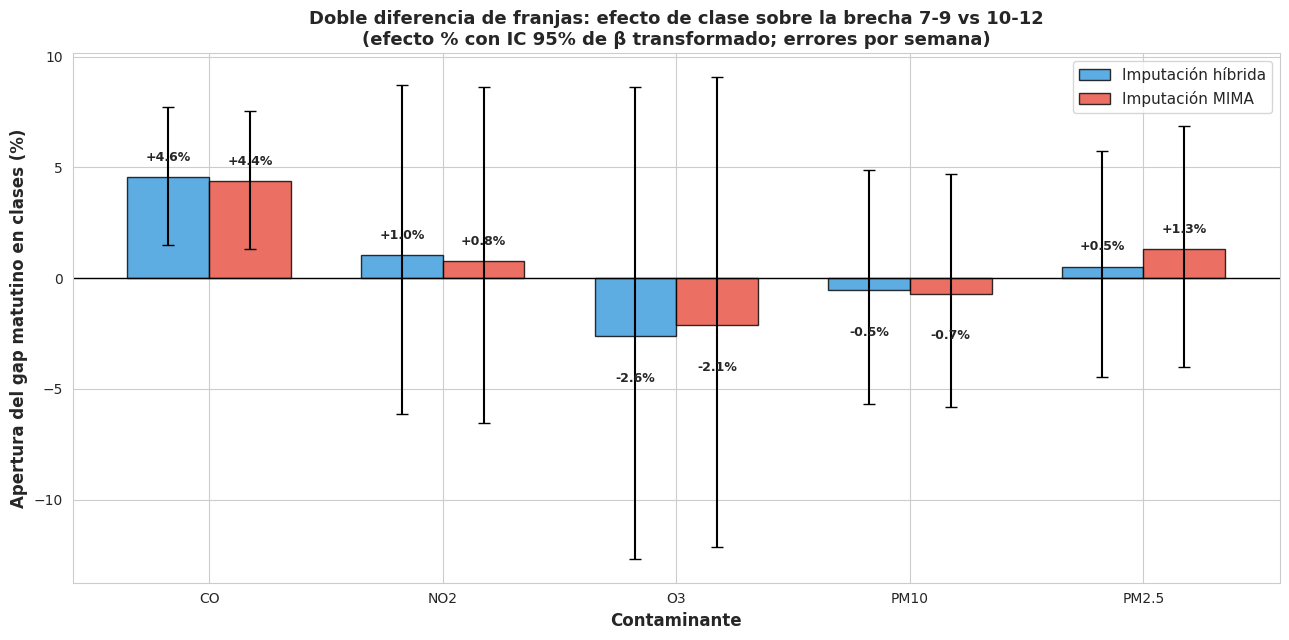

Guardado gráfico en: ../data_processed/graficos_metodos/01_did_franjas_efectos.png


In [4]:
fig, ax = plt.subplots(figsize=(13, 6.5))

did_h = resultados['hibrido']['did_franjas']['por_var']
did_m = resultados['MIMA']['did_franjas']['por_var']

x = np.arange(len(contaminantes))
width = 0.35
for desplazamiento, did, etiqueta, color in [(-width/2, did_h, 'Imputación híbrida', '#3498db'),
                                             (width/2, did_m, 'Imputación MIMA', '#e74c3c')]:
    valores = [did[f'gap_{c}']['pct'] for c in contaminantes]
    err_lo = [did[f'gap_{c}']['pct'] - did[f'gap_{c}']['ci_lo_pct'] for c in contaminantes]
    err_hi = [did[f'gap_{c}']['ci_hi_pct'] - did[f'gap_{c}']['pct'] for c in contaminantes]
    bars = ax.bar(x + desplazamiento, valores, width, yerr=[err_lo, err_hi],
                  label=etiqueta, color=color, alpha=0.8, edgecolor='black', capsize=4)
    for bar, c in zip(bars, contaminantes):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (0.6 if bar.get_height() >= 0 else -2.2),
                f"{did[f'gap_{c}']['pct']:+.1f}%",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(contaminantes)
ax.set_xlabel('Contaminante', fontsize=12, fontweight='bold')
ax.set_ylabel('Apertura del gap matutino en clases (%)', fontsize=12, fontweight='bold')
ax.set_title('Doble diferencia de franjas: efecto de clase sobre la brecha 7-9 vs 10-12\n(efecto % con IC 95% de β transformado; errores por semana)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(graficos_dir / '01_did_franjas_efectos.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado gráfico en: {graficos_dir / '01_did_franjas_efectos.png'}")

## 5. Diagnóstico de residuos: Durbin-Watson y función de autocorrelación

Diagnóstico: examinar cuánta autocorrelación queda en los residuos del diseño (el
diagnóstico aporta evidencia parcial; no demuestra que la dependencia desaparezca).
El estadístico de Durbin-Watson sobre los residuos ordenados en el tiempo,

$$ DW = \frac{\sum_{t=2}^{n} (\hat\varepsilon_t - \hat\varepsilon_{t-1})^2}{\sum_{t=1}^{n} \hat\varepsilon_t^2} \approx 2(1 - \hat\rho_1), $$

vale ~2 si no hay correlación de primer orden ($\hat\rho_1 \approx 0$), <2 con
correlación positiva y >2 con negativa. Se calcula POR ESTACIÓN (mezclar estaciones
fabricaría saltos artificiales) y se compara el modelo en NIVELES contra el modelo
en GAP: la resta entre franjas debería llevarse buena parte de la memoria del día.

Nota de implementación (efectos fijos): en este repo los
efectos fijos entran como variables indicadoras en la matriz de diseño (equivale en
R a `lm(y ~ clase + factor(estacion) + factor(mes) + factor(dow))`, o con paquetes
especializados `fixest::feols(y ~ clase | estacion + mes + dow, cluster = ~semana)`;
en Python, `statsmodels` con dummies — lo que hace este código — o
`linearmodels.PanelOLS` con `entity_effects`). El estimador es el mismo en todos.

In [5]:
from statsmodels.stats.stattools import durbin_watson

panel_diag = pd.read_csv('../data_processed/panel_pico_hibrido.csv', parse_dates=['date'])
gaps_diag = pd.read_csv('../data_processed/gaps_franjas_hibrido.csv', parse_dates=['date'])

def residuos_por_estacion(df, columna_y):
    """
    OLS y ~ clase + mes + dow dentro de UNA estación; residuos en orden temporal.
    """
    df = df.dropna(subset=[columna_y]).sort_values('date')
    X = pd.concat([pd.Series(1.0, index=df.index, name='const'), df['clase'].astype(float),
                   pd.get_dummies(df['mes'], prefix='mes', drop_first=True).astype(float),
                   pd.get_dummies(df['dow'], prefix='dow', drop_first=True).astype(float)], axis=1)
    beta, *_ = np.linalg.lstsq(X.values, df[columna_y].values, rcond=None)
    return df[columna_y].values - X.values @ beta

filas_dw = []
for estacion_m in sorted(panel_diag['estacion'].unique()):
    fila = {'estacion': estacion_m}
    for c in contaminantes:
        r_nivel = residuos_por_estacion(panel_diag[panel_diag['estacion'] == estacion_m], f'l_{c}')
        r_gap = residuos_por_estacion(gaps_diag[gaps_diag['estacion'] == estacion_m], f'gap_{c}')
        fila[f'{c}_nivel'] = round(durbin_watson(r_nivel), 2)
        fila[f'{c}_gap'] = round(durbin_watson(r_gap), 2)
    filas_dw.append(fila)
tabla_dw = pd.DataFrame(filas_dw)

print("=" * 70)
print("DURBIN-WATSON POR ESTACIÓN (nivel log vs gap; ~2 = sin correlación de orden 1)")
print("=" * 70)
print(tabla_dw.to_string(index=False))
tabla_dw.to_csv(resultados_dir / 'durbin_watson_por_estacion.csv', index=False)

dw_nivel_medio = tabla_dw[[f'{c}_nivel' for c in contaminantes]].values.mean()
dw_gap_medio = tabla_dw[[f'{c}_gap' for c in contaminantes]].values.mean()
print(f"\nPromedio DW en niveles: {dw_nivel_medio:.2f} | promedio DW en gaps: {dw_gap_medio:.2f}")
print("=> La resta entre franjas reduce considerablemente la autocorrelación de primer orden")
print("   (los gaps quedan más cerca de 2 que los niveles), pero DW no demuestra que la")
print("   elimine ni dice nada de rezagos mayores a uno: eso se examina abajo con la ACF.")
print(f"\nGuardado en: {resultados_dir / 'durbin_watson_por_estacion.csv'}")

DURBIN-WATSON POR ESTACIÓN (nivel log vs gap; ~2 = sin correlación de orden 1)
 estacion  CO_nivel  CO_gap  NO2_nivel  NO2_gap  O3_nivel  O3_gap  PM10_nivel  PM10_gap  PM2.5_nivel  PM2.5_gap
   CENTRO      0.62    1.88       1.35     1.72      1.10    1.30        1.02      1.86         1.22       1.86
 NORESTE3      0.34    1.41       1.18     1.58      1.48    1.39        1.10      1.92         1.28       1.60
NOROESTE3      0.39    1.61       1.01     1.61      1.46    1.33        1.06      1.86         1.02       1.63
   NORTE2      1.01    1.70       1.03     1.60      1.20    1.26        1.11      1.86         1.31       1.72
      SUR      0.39    1.56       0.86     1.40      1.49    1.41        0.98      1.72         1.17       1.56
SUROESTE2      0.49    1.39       1.19     1.64      1.11    1.37        1.14      1.93         1.39       1.85

Promedio DW en niveles: 1.05 | promedio DW en gaps: 1.62
=> La resta entre franjas reduce considerablemente la autocorrelación de primer

### La función de autocorrelación (ACF) de los residuos

DW solo mira residuos consecutivos ($\hat\varepsilon_t$ con $\hat\varepsilon_{t-1}$).
Para saber cuánto dura la dependencia hay que mirar varios rezagos: la ACF
$\hat\rho_k = \operatorname{corr}(\hat\varepsilon_t, \hat\varepsilon_{t-k})$ para
$k = 1, \dots, 21$ días, por zona, en niveles y en gaps. Lo que interesa para el
diseño: cuánto queda en $k = 1$, si a $k = 7$ (una semana) la correlación ya es
pequeña, y si más allá de una semana es despreciable. Si la dependencia se extiende
claramente más allá de la semana, el cluster semanal sería insuficiente y el wild
bootstrap del notebook 08 sería la defensa principal.

In [6]:
from statsmodels.tsa.stattools import acf

rezagos = 21
filas_acf = []
for estacion_m in sorted(panel_diag['estacion'].unique()):
    for c in contaminantes:
        for tipo, df_d, col in (('nivel', panel_diag, f'l_{c}'), ('gap', gaps_diag, f'gap_{c}')):
            r = residuos_por_estacion(df_d[df_d['estacion'] == estacion_m], col)
            rho = acf(r, nlags=rezagos, fft=True)
            for k in range(1, rezagos + 1):
                filas_acf.append({'estacion': estacion_m, 'contaminante': c, 'serie': tipo,
                                  'rezago': k, 'acf': round(float(rho[k]), 4)})
tabla_acf = pd.DataFrame(filas_acf)
tabla_acf.to_csv(resultados_dir / 'acf_residuos_por_estacion.csv', index=False)

# Resumen: promedio entre zonas y contaminantes por rezago (y banda aproximada 2/sqrt(n))
n_obs = int(panel_diag.groupby('estacion').size().mean())
banda = 2 / np.sqrt(n_obs)
resumen_acf = (tabla_acf.groupby(['serie', 'rezago'])['acf'].mean().unstack('serie')
               [['nivel', 'gap']].round(3))
resumen_acf.to_csv(resultados_dir / 'acf_residuos_promedio.csv')

print("=" * 70)
print("ACF PROMEDIO DE LOS RESIDUOS (zonas y contaminantes juntos; banda ~ ±%.3f)" % banda)
print("=" * 70)
print(resumen_acf.loc[[1, 2, 3, 5, 7, 10, 14, 21]].to_string())
max_gap_semana = float(tabla_acf[(tabla_acf['serie'] == 'gap') & (tabla_acf['rezago'] >= 8)]['acf'].abs().max())
print(f"\nGap: rezago 1 = {resumen_acf.loc[1, 'gap']:.3f}, rezago 7 = {resumen_acf.loc[7, 'gap']:.3f}, "
      f"rezago 14 = {resumen_acf.loc[14, 'gap']:.3f}; máximo |acf| individual más allá de una semana = {max_gap_semana:.3f}")
print(f"Nivel: rezago 1 = {resumen_acf.loc[1, 'nivel']:.3f}, rezago 7 = {resumen_acf.loc[7, 'nivel']:.3f}, "
      f"rezago 14 = {resumen_acf.loc[14, 'nivel']:.3f}")
print("=> Lectura: la resta entre franjas baja la dependencia en todos los rezagos, pero no")
print("   la elimina; el cluster semanal cubre la correlación dentro de la semana y el wild")
print("   bootstrap (notebook 08) protege la inferencia frente a lo que quede.")

ACF PROMEDIO DE LOS RESIDUOS (zonas y contaminantes juntos; banda ~ ±0.060)
serie   nivel    gap
rezago              
1       0.474  0.190
2       0.298  0.090
3       0.239  0.059
5       0.180  0.034
7       0.173  0.024
10      0.154  0.019
14      0.115  0.002
21      0.113  0.003

Gap: rezago 1 = 0.190, rezago 7 = 0.024, rezago 14 = 0.002; máximo |acf| individual más allá de una semana = 0.150
Nivel: rezago 1 = 0.474, rezago 7 = 0.173, rezago 14 = 0.115
=> Lectura: la resta entre franjas baja la dependencia en todos los rezagos, pero no
   la elimina; el cluster semanal cubre la correlación dentro de la semana y el wild
   bootstrap (notebook 08) protege la inferencia frente a lo que quede.


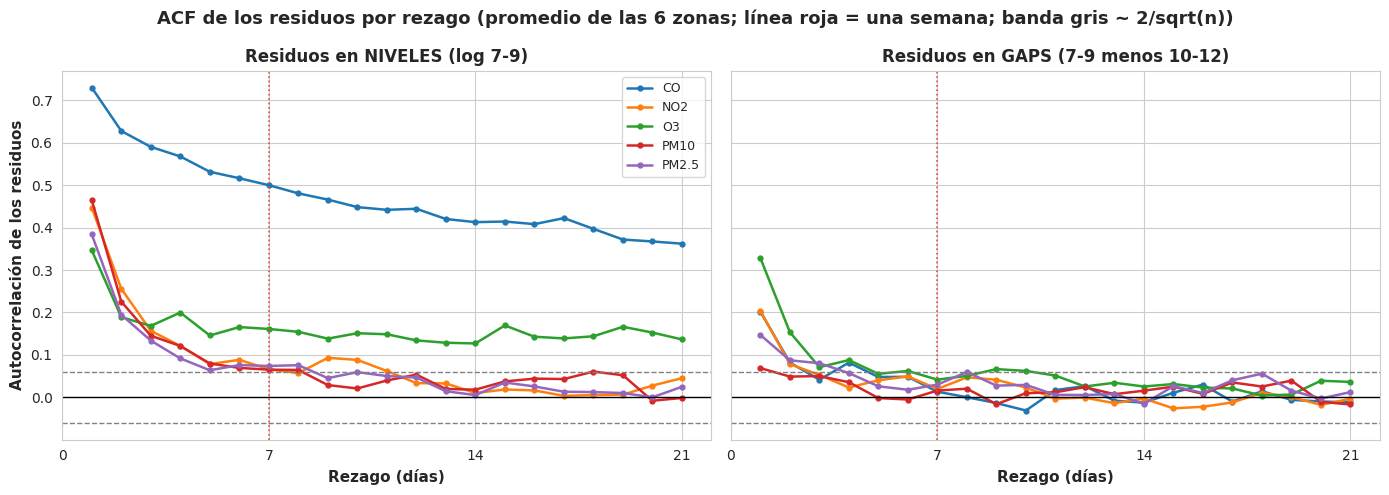

Guardado en: ../data_processed/resultados_metodos/acf_residuos_por_estacion.csv y ../data_processed/resultados_metodos/acf_residuos_promedio.csv
Guardado gráfico en: ../data_processed/graficos_metodos/05_acf_residuos.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, tipo, titulo in zip(axes, ['nivel', 'gap'], ['Residuos en NIVELES (log 7-9)', 'Residuos en GAPS (7-9 menos 10-12)']):
    for c in contaminantes:
        sub = (tabla_acf[(tabla_acf['serie'] == tipo) & (tabla_acf['contaminante'] == c)]
               .groupby('rezago')['acf'].mean())
        ax.plot(sub.index, sub.values, marker='o', markersize=3.5, linewidth=1.8, label=c)
    ax.axhline(0, color='black', linewidth=1)
    ax.axhline(banda, color='gray', linestyle='--', linewidth=1)
    ax.axhline(-banda, color='gray', linestyle='--', linewidth=1)
    ax.axvline(7, color='#e74c3c', linestyle=':', linewidth=1.2)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Rezago (días)', fontsize=11, fontweight='bold')
    ax.set_xticks(range(0, rezagos + 1, 7))
axes[0].set_ylabel('Autocorrelación de los residuos', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
fig.suptitle('ACF de los residuos por rezago (promedio de las 6 zonas; línea roja = una semana; banda gris ~ 2/sqrt(n))',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(graficos_dir / '05_acf_residuos.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado en: {resultados_dir / 'acf_residuos_por_estacion.csv'} y {resultados_dir / 'acf_residuos_promedio.csv'}")
print(f"Guardado gráfico en: {graficos_dir / '05_acf_residuos.png'}")

## 6. Resumen y lectura

In [8]:
print("=" * 70)
print("LECTURA DEL DISEÑO DE FRANJAS (calendario oficial SEP)")
print("=" * 70)
salida_h = resultados['hibrido']
triple = salida_h['triple_dif_wd_menos_we']
co = salida_h['did_franjas']['por_var']['gap_CO']
co_wd = salida_h['solo_entre_semana']['por_var']['gap_CO']
co_we = salida_h['solo_fin_de_semana']['por_var']['gap_CO']
p_conj = salida_h['did_franjas']['p_chi2']
individuales = [c for c in contaminantes if salida_h['did_franjas']['por_var'][f'gap_{c}']['p'] < 0.05]
print(f"1. El efecto conjunto {'rechaza' if p_conj < 0.05 else 'NO rechaza'} cero (p = {p_conj}).")
print(f"2. Asociaciones individuales significativas: {', '.join(individuales) if individuales else 'ninguna'}."
      f" CO: {co['pct']:+.1f}% [{co['ci_lo_pct']}, {co['ci_hi_pct']}] (p = {co['p']}).")
print(f"3. CO entre semana {co_wd['pct']:+.1f}% (p = {co_wd['p']}) contra {co_we['pct']:+.1f}% en fin de")
print(f"   semana (p = {co_we['p']}); triple diferencia delta = {triple['CO']['delta_beta']:+.3f},")
print(f"   p = {triple['CO']['p_aprox']} ({'significativa' if triple['CO']['p_aprox'] < 0.05 else 'al borde' if triple['CO']['p_aprox'] < 0.10 else 'no significativa'}).")
p_we = salida_h['solo_fin_de_semana']['p_chi2']
we_sig = [c for c in contaminantes if salida_h['solo_fin_de_semana']['por_var'][f'gap_{c}']['p'] < 0.05]
if p_we < 0.05:
    print(f"4. ADVERTENCIA: el conjunto de fin de semana también rechaza (p = {p_we}), con")
    print(f"   contaminantes individualmente significativos: {', '.join(we_sig) if we_sig else 'ninguno'}.")
    print(f"   Lo que se mueva en fin de semana no es tráfico escolar; algo más cambia entre")
    print(f"   periodos lectivos y de vacaciones (actividad general, viajes) y toca decirlo tal cual.")
else:
    print(f"4. El conjunto de fin de semana no rechaza (p = {p_we}), como pide una lectura de")
    print(f"   tráfico escolar (sin entrada escolar, sin efecto).")
p_pc, p_pv = salida_h['placebo_clases']['p_chi2'], salida_h['placebo_vacaciones']['p_chi2']
def _lee(p):
    return 'limpia' if p >= 0.10 else 'al borde' if p >= 0.05 else 'RECHAZA (revisar)'
print(f"5. Pruebas de falsación (clase falsa): dentro de clases {_lee(p_pc)} (p = {p_pc});")
print(f"   dentro de vacaciones {_lee(p_pv)} (p = {p_pv}; con MIMA {resultados['MIMA']['placebo_vacaciones']['p_chi2']}).")
print(f"   Se leen como evidencia de consistencia, no como demostración del diseño.")
print(f"6. Las dos imputaciones cuentan la misma historia (CO MIMA: "
      f"{resultados['MIMA']['did_franjas']['por_var']['gap_CO']['pct']:+.1f}%).")
sin_mes = salida_h['sin_efectos_fijos_de_mes']['por_var']
movidos = [c for c in contaminantes
           if abs(sin_mes[f'gap_{c}']['pct'] - salida_h['did_franjas']['por_var'][f'gap_{c}']['pct']) >= 3]
print(f"7. Los efectos fijos de mes mueven en 3 puntos o más a: {', '.join(movidos) if movidos else 'ninguno'}.")
for c in movidos:
    print(f"   {c}: {sin_mes[f'gap_{c}']['pct']:+.1f}% sin mes -> "
          f"{salida_h['did_franjas']['por_var'][f'gap_{c}']['pct']:+.1f}% con mes")
if movidos:
    print(f"   Lo que se va al controlar el mes es temporada, no calendario escolar: la brecha cruda")
    print(f"   de las curvas diurnas la trae puesta. CO es el único que conserva su ensanchamiento.")

print('\nFINALIZADO')

LECTURA DEL DISEÑO DE FRANJAS (calendario oficial SEP)
1. El efecto conjunto rechaza cero (p = 0.000207).
2. Asociaciones individuales significativas: CO. CO: +4.6% [1.49, 7.71] (p = 0.003312).
3. CO entre semana +5.5% (p = 0.003029) contra +1.4% en fin de
   semana (p = 0.467087); triple diferencia delta = +0.040,
   p = 0.1326 (no significativa).
4. El conjunto de fin de semana no rechaza (p = 0.052398), como pide una lectura de
   tráfico escolar (sin entrada escolar, sin efecto).
5. Pruebas de falsación (clase falsa): dentro de clases limpia (p = 0.506341);
   dentro de vacaciones RECHAZA (revisar) (p = 0.046307; con MIMA 0.053109).
   Se leen como evidencia de consistencia, no como demostración del diseño.
6. Las dos imputaciones cuentan la misma historia (CO MIMA: +4.4%).
7. Los efectos fijos de mes mueven en 3 puntos o más a: NO2, O3, PM2.5.
   NO2: +6.5% sin mes -> +1.0% con mes
   O3: +5.6% sin mes -> -2.6% con mes
   PM2.5: +9.0% sin mes -> +0.5% con mes
   Lo que se va al co